In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import plotly.express as px
 

colnames=["age", "workclass","fnlwgt", "education", "education-num" , "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"] 
df = pd.read_csv('adult.data', names=colnames, header=None)

def col_filter(x):
    if isinstance(x, str):  # check if x is str
        return x.strip() if x.strip() != '?' else None
    else:
        return x

possible_values = {}
df_filtered = pd.DataFrame()  # empty dataframe to store updated values

for col in colnames:

    
    df_filtered[col] = df[col].apply(col_filter)
    all_attributes = col, df_filtered[col].unique()
    print(all_attributes[0])


    possible_values[col] = all_attributes[1]



age
workclass
fnlwgt
education
education-num
marital-status
occupation
relationship
race
sex
capital-gain
capital-loss
hours-per-week
native-country
income


In [30]:
df_scenerio3 = df_filtered[["native-country", "income"]] #taking two columns in pd data frame



df_scenerio3["income"] = df_scenerio3["income"].apply(
    lambda x: 0 if x == "<=50K" else 1
)

# print(df_scenerio1)

df_new = df_scenerio3.groupby(["native-country"]).mean()

df_new["income"] = df_new["income"].apply(
    lambda x: x*100
)

df_new = df_new.reset_index()   #using reset we can ungroup 
print(df_new)
ax = df_new.line(x="native-country", y="income")

plt.show()

                native-country     income
0                     Cambodia  36.842105
1                       Canada  32.231405
2                        China  26.666667
3                     Columbia   3.389831
4                         Cuba  26.315789
5           Dominican-Republic   2.857143
6                      Ecuador  14.285714
7                  El-Salvador   8.490566
8                      England  33.333333
9                       France  41.379310
10                     Germany  32.116788
11                      Greece  27.586207
12                   Guatemala   4.687500
13                       Haiti   9.090909
14          Holand-Netherlands   0.000000
15                    Honduras   7.692308
16                        Hong  30.000000
17                     Hungary  23.076923
18                       India  40.000000
19                        Iran  41.860465
20                     Ireland  20.833333
21                       Italy  34.246575
22                     Jamaica  12

/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


AttributeError: 'DataFrame' object has no attribute 'line'

/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/shithi/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


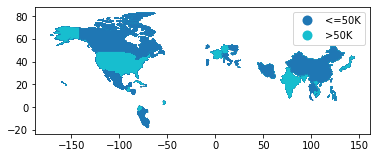

In [24]:

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

country_income = df_filtered[["native-country", "income"]]
country_income["name"] = country_income["native-country"]

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world['name'] = world['name'].replace("United States of America", "United-States")

map = pd.merge(country_income, world, how="inner", on=["name"])
map_gpd = gpd.GeoDataFrame(map)
map_gpd.plot(
    column= 'income',
    legend=True,
    # legend_kwds={'label': "income in native country",
    #                     'orientation': "horizontal"}

);
plt.show()


In [15]:
country_income["native-country"].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', None, 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [23]:
world['name'].replace("United States of America", "United-States")

0                     Fiji
1                 Tanzania
2                W. Sahara
3                   Canada
4            United-States
              ...         
172                 Serbia
173             Montenegro
174                 Kosovo
175    Trinidad and Tobago
176               S. Sudan
Name: name, Length: 177, dtype: object

In [ ]:
world["name"]

In [7]:
df_new

,income
native-country,
Cambodia,36.842105
Canada,32.231405
China,26.666667
Columbia,3.389831
Cuba,26.315789
Dominican-Republic,2.857143
Ecuador,14.285714
El-Salvador,8.490566
England,33.333333


In [6]:
df_scenerio3

,native-country,income
0,United-States,0
1,United-States,0
2,United-States,0
3,United-States,0
4,Cuba,0
...,...,...
32556,United-States,0
32557,United-States,1
32558,United-States,0
32559,United-States,0
